# Слкуни Герман РТ5-61Б
## НИР по анализу шахматных партий

## 1. Загрузка данных

### Подключение библиотек

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV

### Загрузка данных

In [34]:
df = pd.read_csv('games.csv')
df.head(2)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4


## 2. Анализ датасета

### Общая информация о датасете

In [29]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


### Целевая переменная - winner. Проанализируем, как часто выигрывают белые, черные или случаются ничьи

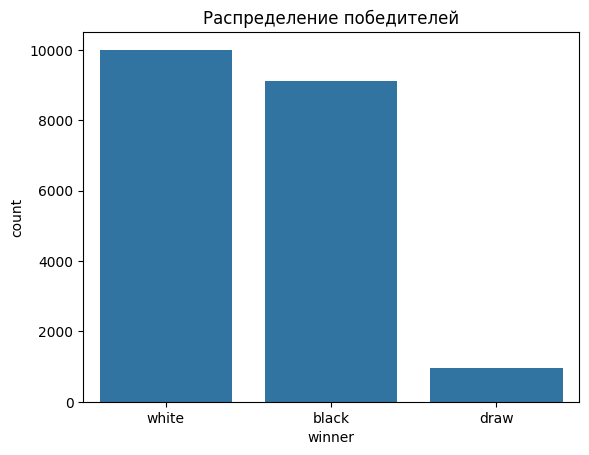

winner
white    0.498604
black    0.454033
draw     0.047363
Name: proportion, dtype: float64


In [30]:
sns.countplot(x='winner', data=df)
plt.title('Распределение победителей')
plt.show()

print(df['winner'].value_counts(normalize=True))

### Проанализируем, какой рейтинг у игроков в датасете

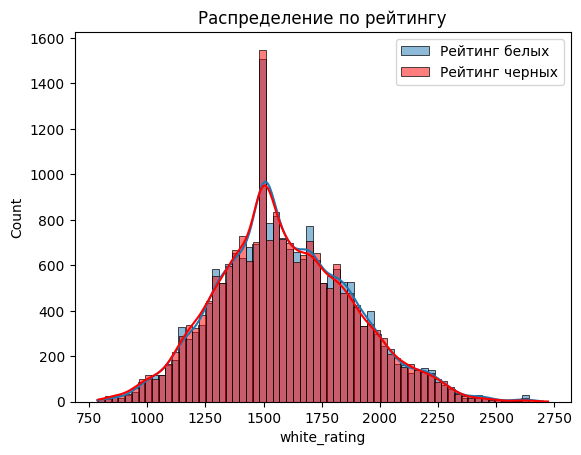

Средний рейтинг белых: 1596.6318675840064
Средний рейтинг черных: 1588.8319872370128


In [31]:
sns.histplot(df['white_rating'], label='Рейтинг белых', kde=True)
sns.histplot(df['black_rating'], color='red', label='Рейтинг черных', kde=True)
plt.legend()
plt.title('Распределение по рейтингу')
plt.show()

print(f"Средний рейтинг белых: {df['white_rating'].mean()}")
print(f"Средний рейтинг черных: {df['black_rating'].mean()}")

### Свяжем разницу рейтинга игрока с победой

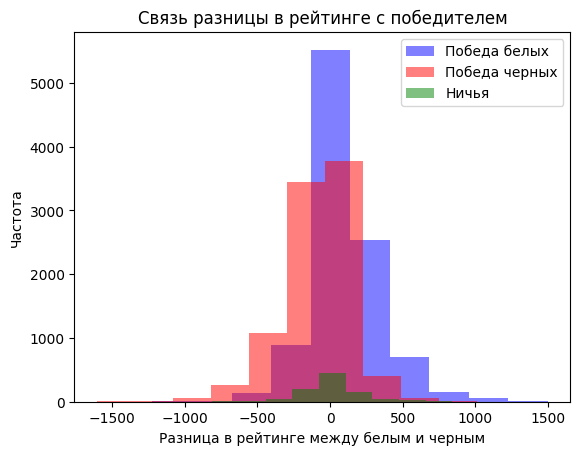

winner
black   -88.981113
draw     14.348421
white    95.307469
Name: rating_difference, dtype: float64


In [35]:
df['rating_difference'] = df['white_rating'] - df['black_rating']

white_wins = df[df['winner'] == 'white']['rating_difference']
black_wins = df[df['winner'] == 'black']['rating_difference']
draws = df[df['winner'] == 'draw']['rating_difference']

plt.hist(white_wins, alpha=0.5, label='Победа белых', color='blue')
plt.hist(black_wins, alpha=0.5, label='Победа черных', color='red')
plt.hist(draws, alpha=0.5, label='Ничья', color='green')
plt.xlabel('Разница в рейтинге между белым и черным')
plt.ylabel('Частота')
plt.legend()
plt.title('Связь разницы в рейтинге с победителем')
plt.show()

print(df.groupby('winner')['rating_difference'].mean())

### Анализ количества ходов

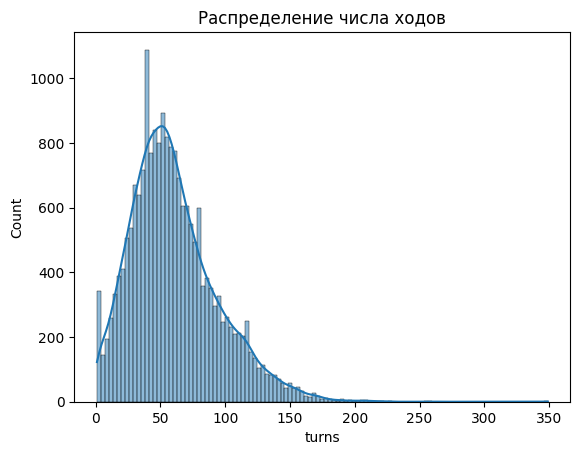

Среднее количество ходов: 60.46599860404826


In [33]:
sns.histplot(df['turns'], kde=True)
plt.title('Распределение числа ходов')
plt.show()

print(f"Среднее количество ходов: {df['turns'].mean()}")

### Корелляционный анализ

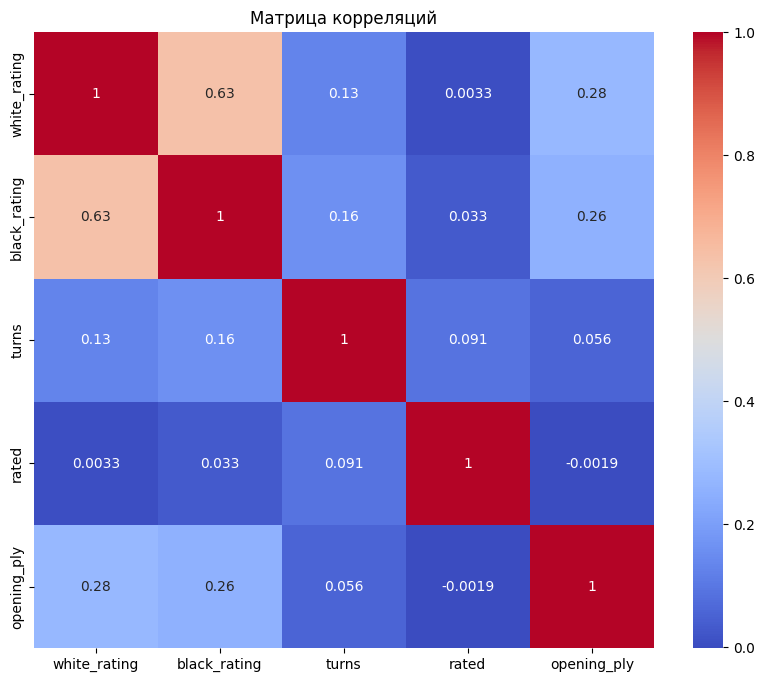

In [36]:
features = ['white_rating', 'black_rating', 'turns', 'rated', 'opening_ply']
correlation_matrix = df[features].corr(method='pearson') 

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

## 3. Подготовка данных

### Удалим варианты с ничьей

In [9]:
df = df[df['winner'] != 'draw']

### Выберем признаки следующим образом

In [10]:
features = ['white_rating', 'black_rating', 'turns', 'rated', 'opening_ply', 'rating_difference']
target = 'winner'

X = df[features]
y = df[target]

### Кодирование категориальных признаков и преобразование типов

In [11]:
X['rated'] = X['rated'].astype(int)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(label_encoder.classes_)

['black' 'white']


C:\Users\user\AppData\Local\Temp\ipykernel_24248\3313263343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['rated'] = X['rated'].astype(int)


### Масштабирование численных признаков

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X[:5])

[[-0.3231754  -1.36220241 -1.42958401 -2.05029357  0.07005173  1.20298556]
 [-0.93709099 -1.12093863 -1.3367311   0.48773503 -0.28929014  0.21354943]
 [-0.33697125 -0.29719515  0.05606259  0.48773503 -0.648632   -0.04577859]
 [-0.5335622  -0.45573992  0.05606259  0.48773503 -0.648632   -0.08966487]
 [-0.24384923 -0.40404054  1.10839561  0.48773503  0.07005173  0.18562179]]


### Разделение данных на обучающую и тестовую выборки

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (15286, 6)
Размер тестовой выборки: (3822, 6)


## 4. Построение моделей

### Построение модели логистической регрессии

In [21]:
# Инициализация модели
logistic_regression = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr')

# Обучение модели
logistic_regression.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_lr = logistic_regression.predict(X_test)

# Оценка модели
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='macro', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='macro', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)

print(f"Accuracy: {accuracy_lr}")
print(f"Precision (macro): {precision_lr}")
print(f"Recall (macro): {recall_lr}")
print(f"F1-score (macro): {f1_lr}")

results_lr = {
    'Accuracy': accuracy_lr,
    'Precision (macro)': precision_lr,
    'Recall (macro)': recall_lr,
    'F1-score (macro)': f1_lr
}

Accuracy: 0.6535845107273679
Precision (macro): 0.6534371388682926
Recall (macro): 0.6512145882249676
F1-score (macro): 0.651108108108108


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### Построение модели дерева решений

In [22]:
# Инициализация модели
decision_tree = DecisionTreeClassifier(random_state=42)

# Обучение модели
decision_tree.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_dt = decision_tree.predict(X_test)

# Оценка модели
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='macro', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='macro', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='macro', zero_division=0)

print(f"Accuracy: {accuracy_dt}")
print(f"Precision (macro): {precision_dt}")
print(f"Recall (macro): {recall_dt}")
print(f"F1-score (macro): {f1_dt}")

results_dt = {
    'Accuracy': accuracy_dt,
    'Precision (macro)': precision_dt,
    'Recall (macro)': recall_dt,
    'F1-score (macro)': f1_dt
}

Accuracy: 0.717687074829932
Precision (macro): 0.7172522648089354
Recall (macro): 0.7174096464857036
F1-score (macro): 0.7173131762624771


### Построение модели случайного леса

In [23]:
# Инициализация модели
random_forest = RandomForestClassifier(random_state=42)

# Обучение модели
random_forest.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_rf = random_forest.predict(X_test)

# Оценка модели
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_rf}")
print(f"Precision (macro): {precision_rf}")
print(f"Recall (macro): {recall_rf}")
print(f"F1-score (macro): {f1_rf}")

results_rf = {
    'Accuracy': accuracy_rf,
    'Precision (macro)': precision_rf,
    'Recall (macro)': recall_rf,
    'F1-score (macro)': f1_rf
}

Random Forest Results:
Accuracy: 0.683935112506541
Precision (macro): 0.683353115727003
Recall (macro): 0.6830473327335367
F1-score (macro): 0.6831520855934399


### Построение модели градиентного бустинга

In [24]:
# Инициализация модели
gradient_boosting = GradientBoostingClassifier(random_state=42)

# Обучение модели
gradient_boosting.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_gb = gradient_boosting.predict(X_test)

# Оценка модели
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='macro', zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, average='macro', zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, average='macro', zero_division=0)

print(f"Accuracy: {accuracy_gb}")
print(f"Precision (macro): {precision_gb}")
print(f"Recall (macro): {recall_gb}")
print(f"F1-score (macro): {f1_gb}")

results_gb = {
    'Accuracy': accuracy_gb,
    'Precision (macro)': precision_gb,
    'Recall (macro)': recall_gb,
    'F1-score (macro)': f1_gb
}

Accuracy: 0.7378335949764521
Precision (macro): 0.7375727742742391
Recall (macro): 0.7367563801540453
F1-score (macro): 0.7369935694100719


### Построение модели SVM

In [25]:
# Инициализация модели
svm = SVC(random_state=42, probability=True)

# Обучение модели
svm.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_svm = svm.predict(X_test)

# Оценка модели
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='macro', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)

print(f"Accuracy: {accuracy_svm}")
print(f"Precision (macro): {precision_svm}")
print(f"Recall (macro): {recall_svm}")
print(f"F1-score (macro): {f1_svm}")

results_svm = {
    'Accuracy': accuracy_svm,
    'Precision (macro)': precision_svm,
    'Recall (macro)': recall_svm,
    'F1-score (macro)': f1_svm
}

Accuracy: 0.6577708006279435
Precision (macro): 0.6595173486534356
Recall (macro): 0.6541512145882249
F1-score (macro): 0.653216461891919


### Построение модели KNN

In [26]:
# Инициализация модели
knn = KNeighborsClassifier()

# Обучение модели
knn.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred_knn = knn.predict(X_test)

# Оценка модели
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='macro', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='macro', zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average='macro', zero_division=0)

print(f"Accuracy: {accuracy_knn}")
print(f"Precision (macro): {precision_knn}")
print(f"Recall (macro): {recall_knn}")
print(f"F1-score (macro): {f1_knn}")

results_knn = {
    'Accuracy': accuracy_knn,
    'Precision (macro)': precision_knn,
    'Recall (macro)': recall_knn,
    'F1-score (macro)': f1_knn
}

Accuracy: 0.6234955520669806
Precision (macro): 0.6226302796929051
Recall (macro): 0.6221034210353076
F1-score (macro): 0.6221627208558853


### Сводная таблица результатов

In [27]:
results_df = pd.DataFrame({
    'Logistic Regression': results_lr,
    'Decision Tree': results_dt,
    'Random Forest': results_rf,
    'Gradient Boosting': results_gb,
    'SVM': results_svm,
    'KNN': results_knn
}).T

print(results_df)

                     Accuracy  Precision (macro)  Recall (macro)  \
Logistic Regression  0.653585           0.653437        0.651215   
Decision Tree        0.717687           0.717252        0.717410   
Random Forest        0.683935           0.683353        0.683047   
Gradient Boosting    0.737834           0.737573        0.736756   
SVM                  0.657771           0.659517        0.654151   
KNN                  0.623496           0.622630        0.622103   

                     F1-score (macro)  
Logistic Regression          0.651108  
Decision Tree                0.717313  
Random Forest                0.683152  
Gradient Boosting            0.736994  
SVM                          0.653216  
KNN                          0.622163  


## 5. Подбор гиперпараметров

### Логистическая регрессия

In [17]:
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

f1_scorer = make_scorer(f1_score)

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train, y_train)

print("Лучшие параметры для логистической регрессии:", grid_search_lr.best_params_)
print("Лучший F1-Score для логистической регрессии:", grid_search_lr.best_score_)

best_lr = grid_search_lr.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры для логистической регрессии: {'C': 0.001, 'penalty': 'l1', 'solver': 'saga'}
Лучший F1-Score для логистической регрессии: 0.705575846566349


### Дерево решений

In [18]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 3, 5, 7]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print("Лучшие параметры для дерева решений:", grid_search_dt.best_params_)
print("Лучший F1-Score для дерева решений:", grid_search_dt.best_score_)

best_dt = grid_search_dt.best_estimator_

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Лучшие параметры для дерева решений: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 15}
Лучший F1-Score для дерева решений: 0.7366770954286895


### Случайный лес

In [19]:
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 3, 5, 7]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Лучшие параметры для случайного леса:", grid_search_rf.best_params_)
print("Лучший F1-Score для случайного леса:", grid_search_rf.best_score_)

best_rf = grid_search_rf.best_estimator_

Fitting 3 folds for each of 768 candidates, totalling 2304 fits
Лучшие параметры для случайного леса: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Лучший F1-Score для случайного леса: 0.7086449787555473


### Градиентный бустинг

In [20]:
param_grid_gb = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_train, y_train)

print("Лучшие параметры для градиентного бустинга:", grid_search_gb.best_params_)
print("Лучший F1-Score для градиентного бустинга:", grid_search_gb.best_score_)

best_gb = grid_search_gb.best_estimator_

Fitting 3 folds for each of 2304 candidates, totalling 6912 fits
Лучшие параметры для градиентного бустинга: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 400, 'subsample': 1.0}
Лучший F1-Score для градиентного бустинга: 0.892037463801575


### SVM

In [14]:
param_grid_svm = {
    'C': np.logspace(-3, 3, 7),
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

f1_scorer = make_scorer(f1_score)

random_search_svm = RandomizedSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    n_iter=10,  # Количество случайных комбинаций для перебора
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_svm.fit(X_train, y_train)

print("Лучшие параметры для SVM:", random_search_svm.best_params_)
print("Лучший F1-Score для SVM:", random_search_svm.best_score_)

best_svm = random_search_svm.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры для SVM: {'kernel': 'poly', 'gamma': 0.1, 'C': 0.01}
Лучший F1-Score для SVM: 0.7071762182025997


### KNN


In [15]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train, y_train)

print("Лучшие параметры для KNN:", grid_search_knn.best_params_)
print("Лучший F1-Score для KNN:", grid_search_knn.best_score_)

best_knn = grid_search_knn.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры для KNN: {'n_neighbors': 13, 'p': 1, 'weights': 'distance'}
Лучший F1-Score для KNN: 0.6665767117901843


### Оценим на тестовых данных

In [39]:
# Обучение и оценка baseline моделей
# Logistic Regression
logistic_regression = LogisticRegression(random_state=42, solver='liblinear')
logistic_regression.fit(X_train, y_train)
y_pred_lr_baseline = logistic_regression.predict(X_test)
accuracy_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)
precision_lr_baseline = precision_score(y_test, y_pred_lr_baseline, average='macro', zero_division=0)
recall_lr_baseline = recall_score(y_test, y_pred_lr_baseline, average='macro', zero_division=0)
f1_lr_baseline = f1_score(y_test, y_pred_lr_baseline)

# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt_baseline = decision_tree.predict(X_test)
accuracy_dt_baseline = accuracy_score(y_test, y_pred_dt_baseline)
precision_dt_baseline = precision_score(y_test, y_pred_dt_baseline, average='macro', zero_division=0)
recall_dt_baseline = recall_score(y_test, y_pred_dt_baseline, average='macro', zero_division=0)
f1_dt_baseline = f1_score(y_test, y_pred_dt_baseline)

# Random Forest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf_baseline = random_forest.predict(X_test)
accuracy_rf_baseline = accuracy_score(y_test, y_pred_rf_baseline)
precision_rf_baseline = precision_score(y_test, y_pred_rf_baseline, average='macro', zero_division=0)
recall_rf_baseline = recall_score(y_test, y_pred_rf_baseline, average='macro', zero_division=0)
f1_rf_baseline = f1_score(y_test, y_pred_rf_baseline)

# Gradient Boosting
gradient_boosting = GradientBoostingClassifier(random_state=42)
gradient_boosting.fit(X_train, y_train)
y_pred_gb_baseline = gradient_boosting.predict(X_test)
accuracy_gb_baseline = accuracy_score(y_test, y_pred_gb_baseline)
precision_gb_baseline = precision_score(y_test, y_pred_gb_baseline, average='macro', zero_division=0)
recall_gb_baseline = recall_score(y_test, y_pred_gb_baseline, average='macro', zero_division=0)
f1_gb_baseline = f1_score(y_test, y_pred_gb_baseline)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm_baseline = svm.predict(X_test)
accuracy_svm_baseline = accuracy_score(y_test, y_pred_svm_baseline)
precision_svm_baseline = precision_score(y_test, y_pred_svm_baseline, average='macro', zero_division=0)
recall_svm_baseline = recall_score(y_test, y_pred_svm_baseline, average='macro', zero_division=0)
f1_svm_baseline = f1_score(y_test, y_pred_svm_baseline)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn_baseline = knn.predict(X_test)
accuracy_knn_baseline = accuracy_score(y_test, y_pred_knn_baseline)
precision_knn_baseline = precision_score(y_test, y_pred_knn_baseline, average='macro', zero_division=0)
recall_knn_baseline = recall_score(y_test, y_pred_knn_baseline, average='macro', zero_division=0)
f1_knn_baseline = f1_score(y_test, y_pred_knn_baseline)

# Оценка моделей с лучшими гиперпараметрами на тестовой выборке
# Logistic Regression
y_pred_lr_tuned = best_lr.predict(X_test)
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)

# Decision Tree
y_pred_dt_tuned = best_dt.predict(X_test)
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
precision_dt_tuned = precision_score(y_test, y_pred_dt_tuned, average='macro', zero_division=0)
recall_dt_tuned = recall_score(y_test, y_pred_dt_tuned, average='macro', zero_division=0)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned)

# Random Forest
y_pred_rf_tuned = best_rf.predict(X_test)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)

# Gradient Boosting
y_pred_gb_tuned = best_gb.predict(X_test)
accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test, y_pred_gb_tuned, average='macro', zero_division=0)
recall_gb_tuned = recall_score(y_test, y_pred_gb_tuned, average='macro', zero_division=0)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned)

# SVM
y_pred_svm_tuned = best_svm.predict(X_test)
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
precision_svm_tuned = precision_score(y_test, y_pred_svm_tuned, average='macro', zero_division=0)
recall_svm_tuned = recall_score(y_test, y_pred_svm_tuned, average='macro', zero_division=0)
f1_svm_tuned = f1_score(y_test, y_pred_svm_tuned)

# KNN
y_pred_knn_tuned = best_knn.predict(X_test)
accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
precision_knn_tuned = precision_score(y_test, y_pred_knn_tuned, average='macro', zero_division=0)
recall_knn_tuned = recall_score(y_test, y_pred_knn_tuned, average='macro', zero_division=0)
f1_knn_tuned = f1_score(y_test, y_pred_knn_tuned)

# Создание таблицы сравнения
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN'],
    'F1-Score (Baseline)': [f1_lr_baseline, f1_dt_baseline, f1_rf_baseline, f1_gb_baseline, f1_svm_baseline, f1_knn_baseline],
    'Accuracy (Baseline)': [accuracy_lr_baseline, accuracy_dt_baseline, accuracy_rf_baseline, accuracy_gb_baseline, accuracy_svm_baseline, accuracy_knn_baseline],
    'Precision (Baseline)': [precision_lr_baseline, precision_dt_baseline, precision_rf_baseline, precision_gb_baseline, precision_svm_baseline, precision_knn_baseline],
    'Recall (Baseline)': [recall_lr_baseline, recall_dt_baseline, recall_rf_baseline, recall_gb_baseline, recall_svm_baseline, recall_knn_baseline],
    'F1-Score (Tuned)': [f1_lr_tuned, f1_dt_tuned, f1_rf_tuned, f1_gb_tuned, f1_svm_tuned, f1_knn_tuned],
    'Accuracy (Tuned)': [accuracy_lr_tuned, accuracy_dt_tuned, accuracy_rf_tuned, accuracy_gb_tuned, accuracy_svm_tuned, accuracy_knn_tuned],
    'Precision (Tuned)': [precision_lr_tuned, precision_dt_tuned, precision_rf_tuned, precision_gb_tuned, precision_svm_tuned, precision_knn_tuned],
    'Recall (Tuned)': [recall_lr_tuned, recall_dt_tuned, recall_rf_tuned, recall_gb_tuned, recall_svm_tuned, recall_knn_tuned]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model').T

print(results_df)

Model                 Logistic Regression  Decision Tree  Random Forest  \
F1-Score (Baseline)              0.680502       0.727594       0.698903   
Accuracy (Baseline)              0.653585       0.717687       0.683935   
Precision (Baseline)             0.653437       0.717252       0.683353   
Recall (Baseline)                0.651215       0.717410       0.683047   
F1-Score (Tuned)                 0.696783       0.751625       0.710276   
Accuracy (Tuned)                 0.652276       0.750131       0.697541   
Precision (Tuned)                0.657054       0.750952       0.697005   
Recall (Tuned)                   0.647315       0.751166       0.696914   

Model                 Gradient Boosting       SVM       KNN  
F1-Score (Baseline)            0.751857  0.692958  0.644604  
Accuracy (Baseline)            0.737834  0.657771  0.623496  
Precision (Baseline)           0.737573  0.659517  0.622630  
Recall (Baseline)              0.736756  0.654151  0.622103  
F1-Score (Tune

### Сравним графически

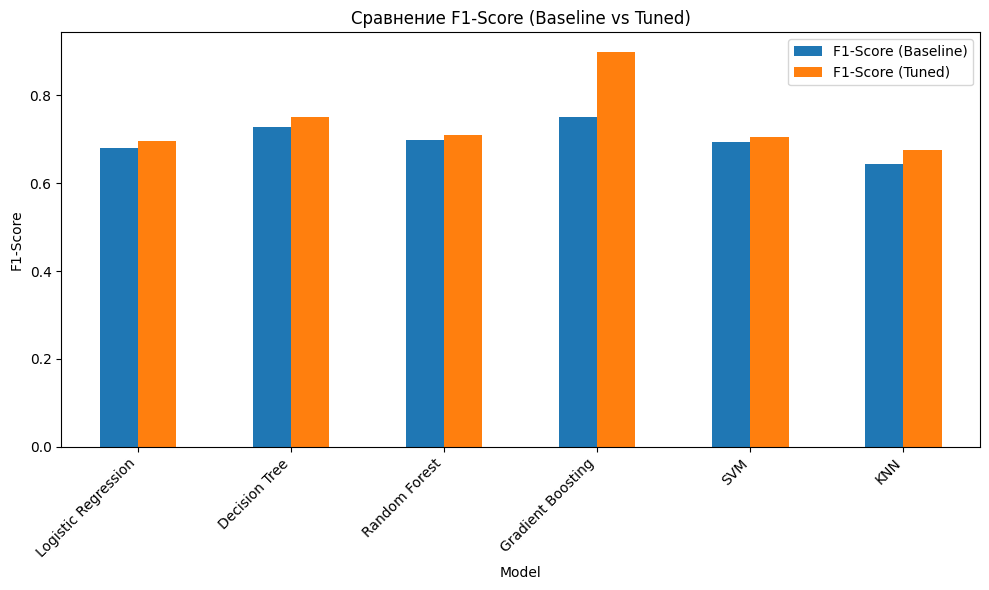

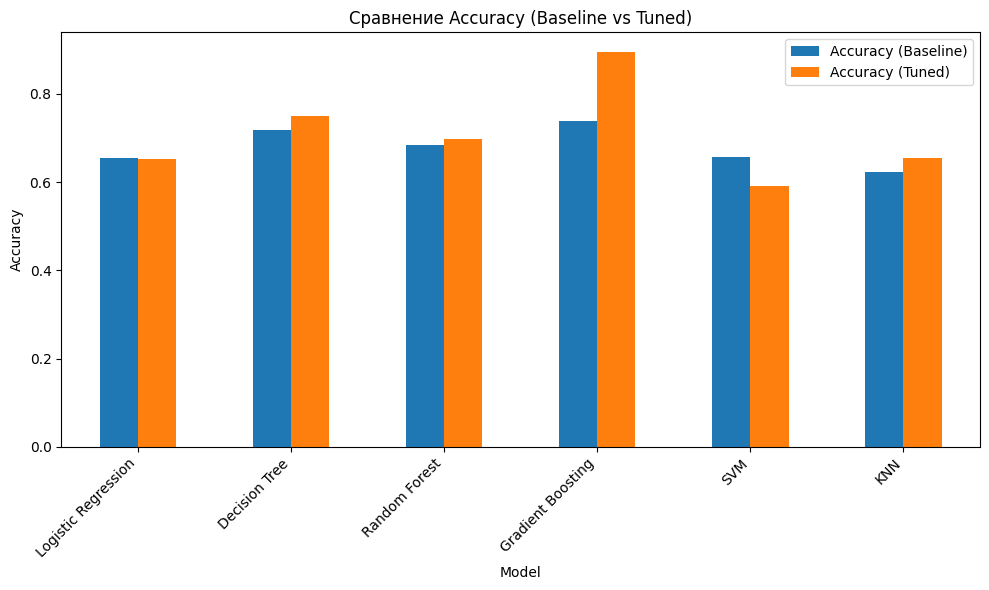

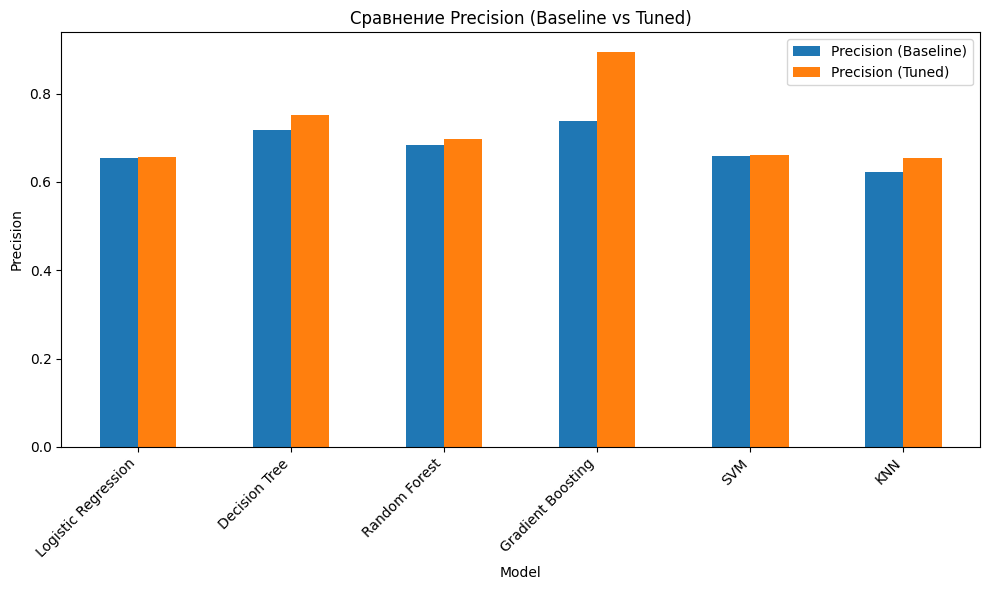

In [41]:
# Создание DataFrame из results
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# Выбор столбцов для графика
f1_scores = results_df[['F1-Score (Baseline)', 'F1-Score (Tuned)']]

# Построение столбчатой диаграммы
ax = f1_scores.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение F1-Score (Baseline vs Tuned)')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

accuracy_data = results_df[['Accuracy (Baseline)', 'Accuracy (Tuned)']]
ax = accuracy_data.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение Accuracy (Baseline vs Tuned)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

precision_data = results_df[['Precision (Baseline)', 'Precision (Tuned)']]
ax = precision_data.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение Precision (Baseline vs Tuned)')
plt.ylabel('Precision')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()